# Alison Chatham
# Module 4 Assignment

In [84]:
import cdsapi
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import xarray as xr
from sklearn.preprocessing import StandardScaler
import pandas as pd
from eofs.xarray import Eof

### Step 1: Create a dataset that contains the monthly means of Sea Surface Temperature anomalies and total column water vapor from Jan 1979-Dec 2024 over the Pacific Basin (65°N to 65°S, 120°E to 60°W) masked out over land - save this to your computer. The data and land sea mask is available here: [https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-monthly-means?tab=download](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-monthly-means?tab=download)

In [75]:
# client = cdsapi.Client()

# dataset = "reanalysis-era5-single-levels-monthly-means"
# request = {
#     "product_type": ["monthly_averaged_reanalysis"],
#     "variable": [
#         "sea_surface_temperature",
#         "total_column_water_vapour",
#         "land_sea_mask"
#     ],
#     "year": [
#         "1979", "1980", "1981",
#         "1982", "1983", "1984",
#         "1985", "1986", "1987",
#         "1988", "1989", "1990",
#         "1991", "1992", "1993",
#         "1994", "1995", "1996",
#         "1997", "1998", "1999",
#         "2000", "2001", "2002",
#         "2003", "2004", "2005",
#         "2006", "2007", "2008",
#         "2009", "2010", "2011",
#         "2012", "2013", "2014",
#         "2015", "2016", "2017",
#         "2018", "2019", "2020",
#         "2021", "2022", "2023",
#         "2024"
#     ],
#     "month": [
#         "01", "02", "03",
#         "04", "05", "06",
#         "07", "08", "09",
#         "10", "11", "12"
#     ],
#     "time": ["00:00"],
#     "data_format": "netcdf",
#     "download_format": "unarchived",
#     "area": [65, 120, -65, 300]
# }

# client.retrieve(dataset, request).download()

In [85]:
ds = xr.open_dataset("ac3a51e127a7e15bb62aa825ae452811.nc")
ds

<xarray.Dataset> Size: 2GB
Dimensions:     (valid_time: 552, latitude: 521, longitude: 721)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 4kB 1979-01-01 ... 2024-12-01
  * latitude    (latitude) float64 4kB 65.0 64.75 64.5 ... -64.5 -64.75 -65.0
  * longitude   (longitude) float64 6kB 120.0 120.2 120.5 ... 299.5 299.8 300.0
    expver      (valid_time) <U4 9kB ...
Data variables:
    sst         (valid_time, latitude, longitude) float32 829MB ...
    tcwv        (valid_time, latitude, longitude) float32 829MB ...
    lsm         (valid_time, latitude, longitude) float32 829MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-10-20T01:20 GRIB to CDM+CF via cfgrib-0.9.1...

In [86]:
# Apply mask: keep ocean only (0 aka where lsm < 0.5)
# Extract static mask (remove time)
mask_static = ds["lsm"].isel(valid_time=0)

# Interpolate mask to SST grid (even if it looks identical)
mask_interp = mask_static.interp_like(ds["sst"])

# Apply ocean mask and verify
ds_ocean = ds.where(mask_interp < 0.5)
print("Valid ocean SST points:", int(np.isfinite(ds_ocean["sst"]).sum()))

Valid ocean SST points: 165912459


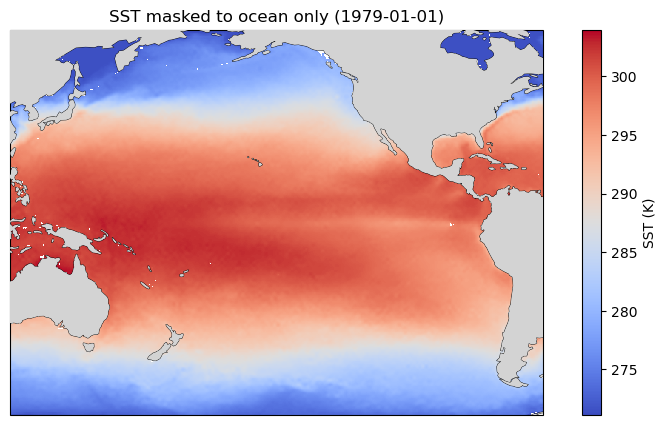

In [87]:
# testing data to see if it makes sense visually
var = "sst" # or "tcwv"
da = ds_ocean[var].isel(valid_time=0)  # first month

plt.figure(figsize=(10,5))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
p = ax.pcolormesh(da.longitude, da.latitude, da, cmap="coolwarm", transform=ccrs.PlateCarree())

# add coastlines & land for reference
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=100)

# focus on Pacific Basin 
ax.set_extent([120, 300, -65, 65], crs=ccrs.PlateCarree())

# colorbar and title
plt.colorbar(p, label=f"{var.upper()} ({da.attrs.get('units','')})")
plt.title(f"{var.upper()} masked to ocean only ({str(da.valid_time.values)[:10]})")
plt.show()

### Step 2: From the dataset shown in 1, compute anomalies by deseasonalizing the data (remove the mean monthly anomaly from the annual mean from each point) and detrend the data. Then, standardize the SST anomalies.  Standardization means subtract the long term mean and divide by the standard deviation.

In [88]:
# From Professor

def _time_as_float(time: xr.DataArray, time_dim: str) -> xr.DataArray:
    # numeric seconds since first timestamp (keeps numbers small)
    return (time - time.isel({time_dim: 0})).astype("timedelta64[s]").astype("int64").astype("float64")

def linear_detrend(obj: xr.DataArray | xr.Dataset, time_dim: str = "time") -> xr.DataArray | xr.Dataset:
    """
    Remove a linear trend y ~ s*(t - t̄_valid) + ȳ_valid at each grid point.
    Closed-form LS using reductions; dask-friendly; handles NaNs.
    """
    t = _time_as_float(obj[time_dim], time_dim)  # (time,)
    def _detrend_da(da: xr.DataArray) -> xr.DataArray:
        da = da.sortby(time_dim).astype("float32")
        if hasattr(da.data, "chunks"):
            da = da.chunk({time_dim: -1})  # one chunk along time
        mask = da.notnull()                                # (time, ...)
        t_b = t.broadcast_like(da)                         # (time, ...)
        t_mean_valid = t_b.where(mask).mean(time_dim, skipna=True)
        tc = t_b - t_mean_valid                            # centered time per point
        num = (da * tc).sum(time_dim, skipna=True)
        den = (tc**2).sum(time_dim, skipna=True)
        slope = xr.where(den > 0, num / den, 0.0)
        ybar  = da.mean(time_dim, skipna=True)
        trend = slope * (t_b - t_mean_valid) + ybar
        return (da - trend).astype("float32")
    return obj.map(_detrend_da) if isinstance(obj, xr.Dataset) else _detrend_da(obj)

def monthly_anom_and_z(
    detr: xr.DataArray | xr.Dataset,
    time_dim: str = "time",
    base_period: tuple[str, str] | None = None,
    ddof: int = 1,
    eps: float = 1e-6,
):
    """
    From linearly-detrended data, remove monthly climatology and compute monthly z-scores.
    Returns (anom, z). Works for Dataset or DataArray.
    """
    clim_src = detr if base_period is None else detr.sel({time_dim: slice(*base_period)})
    key = f"{time_dim}.month"

    clim_mean = clim_src.groupby(key).mean(time_dim, skipna=True)
    anom = detr.groupby(key) - clim_mean

    clim_std = clim_src.groupby(key).std(time_dim, skipna=True, ddof=ddof)
    safe_std = xr.where(clim_std > eps, clim_std, np.nan)
    z = anom.groupby(key) / safe_std
    return anom, z


# # Example:
# # ds is a monthly ERA5 Dataset or DataArray with dimension "time"
# # If Dataset, all variables get processed; if DataArray, just that variable
# # ds = ds.chunk({"time": -1})  # optional: ensure time is a single chunk for speed
# # Optional: keep time in one chunk for speed
# ds = ds.chunk({"valid_time": -1})

# detr = linear_detrend(ds[["sst", "tcrw"]], time_dim="valid_time")   # or just ds if you want all float vars
# anom, z = monthly_anom_and_z(detr, time_dim="valid_time",
#                              base_period=("1981-01-01", "2010-12-31"))  # or None for full-period

# print(type(z), list(z.data_vars))   # should show a Dataset with ['sst','tcrw']

In [89]:
# applying provided functions to dataset
ds_ocean = ds_ocean.chunk({"valid_time": -1})

# detrend
detr = linear_detrend(ds_ocean[["sst", "tcwv"]], time_dim="valid_time")

# deseasonalize and compute anomalies/z-scores
anom, z = monthly_anom_and_z(detr, time_dim="valid_time", base_period=None)

print("Variables in anomaly set:", list(anom.data_vars))
print("Variables in standardized z-score set:", list(z.data_vars))
print(type(z))

Variables in anomaly set: ['sst', 'tcwv']
Variables in standardized z-score set: ['sst', 'tcwv']
<class 'xarray.core.dataset.Dataset'>


In [90]:
# Standardize SST anomalies along the time dimension
sst_anom = anom["sst"]

sst_standardized = ((sst_anom - sst_anom.mean(dim="valid_time")) / sst_anom.std(dim="valid_time"))
sst_standardized.name = "sst_standardized"

# load data into memory for validation
sst_standardized_local = sst_standardized.compute()

# Verify
print("Has valid data:", np.isfinite(sst_standardized_local).any().item())
print("Mean:", float(sst_standardized_local.mean('valid_time', skipna=True).mean())) # approx. 0
print("Std:", float(sst_standardized_local.std('valid_time', skipna=True).mean())) # approx. 1

Has valid data: True
Mean: 6.143303227235108e-11
Std: 1.0


c:\Users\aliso\anaconda3\envs\xarray-climate\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


### Step 3: Perform an EOF analysis on the SST anomalies and plot a map of the first 5 EOFs, following M04N05.

EOF 1: 16.63% of variance explained
EOF 2: 6.19% of variance explained
EOF 3: 4.80% of variance explained
EOF 4: 4.15% of variance explained
EOF 5: 3.75% of variance explained


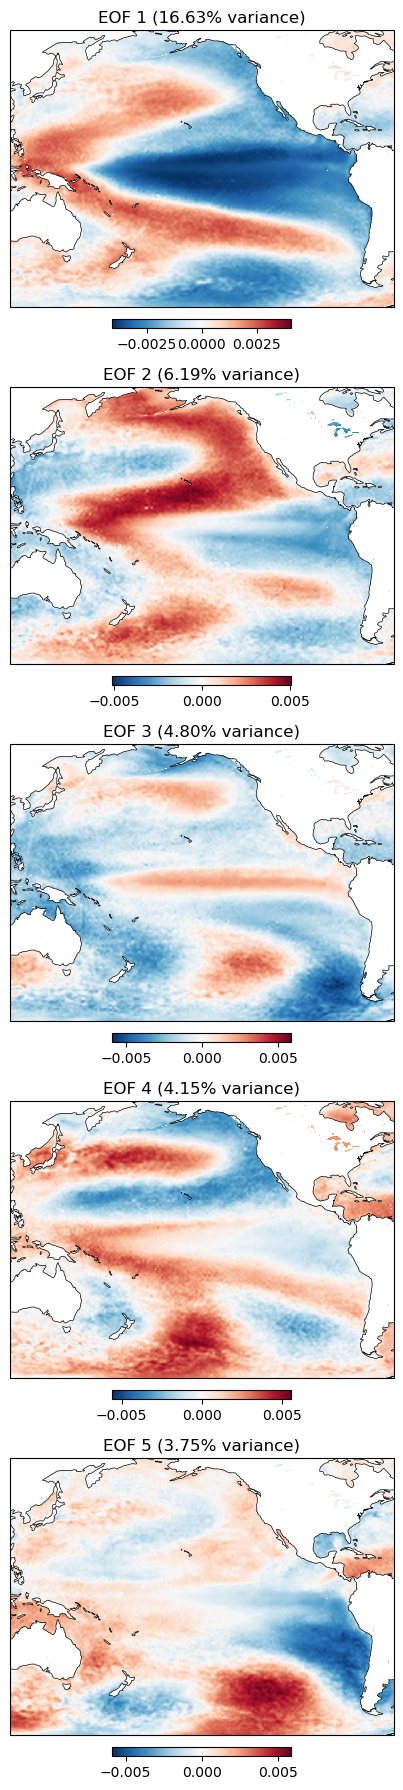

In [91]:
# Rename 'valid_time' for EOF solver compatibility
sst_std = sst_standardized_local.rename({'valid_time': 'time'})

solver = Eof(sst_std)

# Extract first 5 EOFs (spatial patterns) and PCs (time series)
eofs = solver.eofs(neofs=5)
pcs = solver.pcs(npcs=5, pcscaling=1)
variance_fractions = solver.varianceFraction(neigs=5)

# Print explained variance
for i, vf in enumerate(variance_fractions.values):
    print(f"EOF {i+1}: {vf*100:.2f}% of variance explained")

# Plot first 5 EOFs
proj = ccrs.PlateCarree(central_longitude=180)
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(10, 18),
                         subplot_kw={'projection': proj})

for i, ax in enumerate(axes.flat):
    eof = eofs.isel(mode=i)
    im = eof.plot(ax=ax, transform=ccrs.PlateCarree(),
                  cmap='RdBu_r', add_colorbar=False)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.set_title(f"EOF {i+1} ({variance_fractions.values[i]*100:.2f}% variance)")
    ax.set_extent([120, 300, -65, 65], crs=ccrs.PlateCarree())
    fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.04, fraction=0.03)

plt.tight_layout()
plt.show()

### Step 4: Plot the percent of variance explained by the first 10 EOFs.

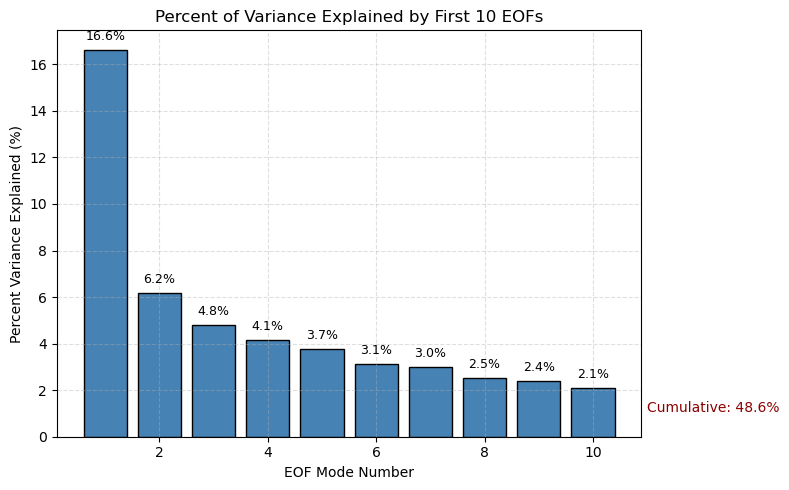

In [95]:
# Compute variance explained for first 10 EOFs
variance_fractions = solver.varianceFraction(neigs=10)

# Convert to percent
variance_percent = variance_fractions.values * 100
eof_nums = np.arange(1, len(variance_percent) + 1)

# Plot
plt.figure(figsize=(8, 5))
plt.bar(eof_nums, variance_percent, color='steelblue', edgecolor='black')

plt.title('Percent of Variance Explained by First 10 EOFs')
plt.xlabel('EOF Mode Number')
plt.ylabel('Percent Variance Explained (%)')

# annotate cumulative variance
cumulative = np.cumsum(variance_percent)
for i, (v, c) in enumerate(zip(variance_percent, cumulative)):
    plt.text(i + 1, v + 0.3, f"{v:.1f}%", ha='center', va='bottom', fontsize=9)
    if i == 9:
        plt.text(i + 2, v / 2, f"Cumulative: {c:.1f}%", fontsize=10, color='darkred')

plt.grid(alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()

The EOF analysis of deseasonalized, detrended, and standardized monthly SST anomalies over the Pacific Basin reveals that the leading modes explain nearly half of the total variance in the dataset. The first EOF represents the dominant large-scale mode of SST variability — typically associated with the El Niño–Southern Oscillation (ENSO). The second EOF explains an additional portion of the variance and is likely related to ENSO asymmetries or Pacific Decadal Oscillation (PDO)-like variability. Beyond the first few modes, the variance explained drops rapidly, with the first 10 EOFs together accounting for approximately 48.6 % of the total variance. This steep decline indicates that most of the SST variability is concentrated in a small number of large-scale, physically meaningful patterns, while higher-order modes represent smaller-scale or more transient fluctuations.

### Step 5: Reconstruct the SST field using the first 5 EOFs and plot a map of the Pearson's correlation coefficient ([xarray.corr](https://docs.xarray.dev/en/stable/generated/xarray.corr.html)) of the reconstructed monthly time series and the "observed" SST time series.

c:\Users\aliso\anaconda3\envs\xarray-climate\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\aliso\anaconda3\envs\xarray-climate\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


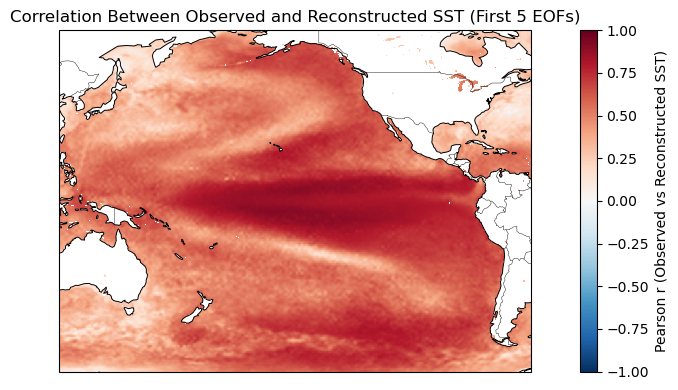

In [ ]:
n_modes = 5 # number of modes to reconstruct

# Reconstruct SST anomalies using the first n_modes
eofs = solver.eofs(neofs=n_modes)
pcs = solver.pcs(npcs=n_modes, pcscaling=1)
reconstructed = (pcs @ eofs.transpose("mode", "latitude", "longitude")).assign_coords(valid_time=pcs["time"])
reconstructed.name = "sst_reconstructed"

# Compute correlation between observed and reconstructed SST
corr_map = xr.corr(sst_std, reconstructed, dim="time")
corr_map.name = "correlation"

# Plot the correlation map
plt.figure(figsize=(10, 4))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
corr_map.plot(ax=ax, transform=ccrs.PlateCarree(), cmap="RdBu_r", vmin=-1, vmax=1, cbar_kwargs={"label": "Pearson r (Observed vs Reconstructed SST)"})
ax.coastlines(linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.set_title(f"Correlation Between Observed and Reconstructed SST (First {n_modes} EOFs)")
plt.tight_layout()
plt.show() # measure of how well your EOFs do

### Step 6: Compute a map of the Pearson's correlation coefficient between SST EOF1 and monthly mean detrended, deseasonalized, and standardized monthly mean column water vapor anomalies (don't mask these over land for the plot).  See anything interesting?

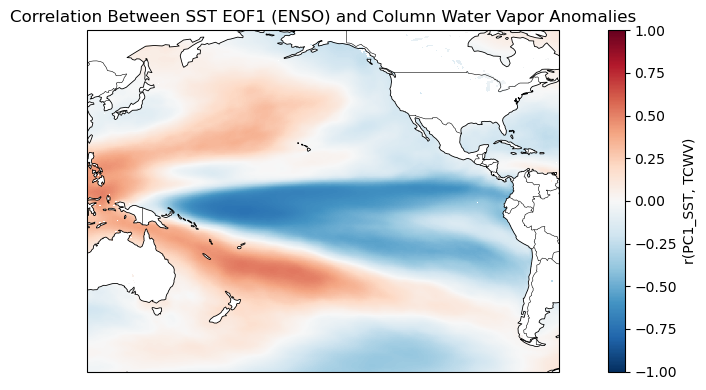

In [102]:
# Extract the first EOF time series
pc1 = pcs.isel(mode=0)
pc1.name = "PC1"

# unify to match tcwv_anom
if "valid_time" in pc1.dims:
    pc1 = pc1.rename({"valid_time": "time"})
if "valid_time" in z.dims:
    z = z.rename({"valid_time": "time"})

tcwv_anom = z["tcwv"]  # standardized anomalies from Step 2
tcwv_anom, pc1 = xr.align(tcwv_anom, pc1, join="inner")

# Compute correlation at each gridpoint
corr_tcwv = xr.corr(tcwv_anom, pc1, dim="time")
corr_tcwv.name = "corr_tcwv_pc1"

# mask land but not for water vapor computation
mask = ds["lsm"].isel(valid_time=0)
corr_tcwv_masked = corr_tcwv.where(mask < 0.5)

# Plot
plt.figure(figsize=(10, 4))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
corr_tcwv_masked.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    cbar_kwargs={"label": "r(PC1_SST, TCWV)"}
)
ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.set_title("Correlation Between SST EOF1 (ENSO) and Column Water Vapor Anomalies")
plt.tight_layout()
plt.show()


*Noting the comment with the random seed on how this figure looks from our class session. 

- western to central tropical Pacific shows strong positive correlations: warmer SSTs (El Niño conditions) are accompanied by increased atmospheric water vapor, consistent with the Clausius–Clapeyron relationship, which predicts higher moisture-holding capacity of air as temperatures rise
- eastern Pacific exhibits negative correlations: pattern reflects cooler SSTs and reduced moisture during El Niño, or conversely, warming and moistening there during La Niña; warming in one region corresponds to cooling in another
- Subtropical regions show weaker, more diffuse correlations, suggesting secondary effects of ENSO on atmospheric moisture; ENSO-driven SST variability influences global moisture distribution extending beyond the equatorial Pacific